In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
from cartopy.util import add_cyclic_point

In [2]:
# data check
"""
ds_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
case = "mon_clim1981-2010.em"

model_list = ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 
              'EC-Earth3', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 
              'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']

for model in model_list[1:2]:
    lead_end = 10
    if model in ['CNRM-ESM2-1', 'MRI-ESM2-0']:
        lead_end = 5
        
    for lead in range(1, lead_end + 1):
        file = f"{ds_dir}/{model}/siconc.YR{lead}.{case}.nc"   
        ds = xr.open_dataset(file)
        print(file)
        print('ds dimension:', ds.dims)
        ds.close()
"""


'\nds_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"\ncase = "mon_clim1981-2010.em"\n\nmodel_list = [\'CanESM5\', \'CMCC-CM2-SR5\', \'CNRM-ESM2-1\', \n              \'EC-Earth3\', \'HadGEM3-GC31-MM\', \'IPSL-CM6A-LR\', \n              \'MIROC6\', \'MPI-ESM1-2-HR\', \'MRI-ESM2-0\', \'NorCPM1\']\n\nfor model in model_list[1:2]:\n    lead_end = 10\n    if model in [\'CNRM-ESM2-1\', \'MRI-ESM2-0\']:\n        lead_end = 5\n        \n    for lead in range(1, lead_end + 1):\n        file = f"{ds_dir}/{model}/siconc.YR{lead}.{case}.nc"   \n        ds = xr.open_dataset(file)\n        print(file)\n        print(\'ds dimension:\', ds.dims)\n        ds.close()\n'

In [3]:
def ensure_latlon(ds):

    ref_file = "/pscratch/sd/j/jungchoi/DCPP/_link/EC-Earth3/areacello.nc"
    ds_ref = xr.open_dataset(ref_file)
    print('EC-Earth, ref:', ds_ref)
    
    ds = ds.assign_coords(longitude = (ds_ref["longitude"]))
    ds_ref.close()
    return ds

<xarray.Dataset> Size: 3MB
Dimensions:    (latitude: 180, longitude: 360, month: 12, nv: 2)
Coordinates:
  * latitude   (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    time_bnds  (month, nv) float32 96B 4.584e+06 4.587e+06 ... 4.62e+06
    siconc     (month, latitude, longitude) float32 3MB nan nan ... 99.7 99.7
Attributes:
    Title:                      Monthly version of HadISST sea ice component
    description:                HadISST sea ice concentration.
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/3/2025 converted to netcdf from pp format
    supplementary_information:  Updat

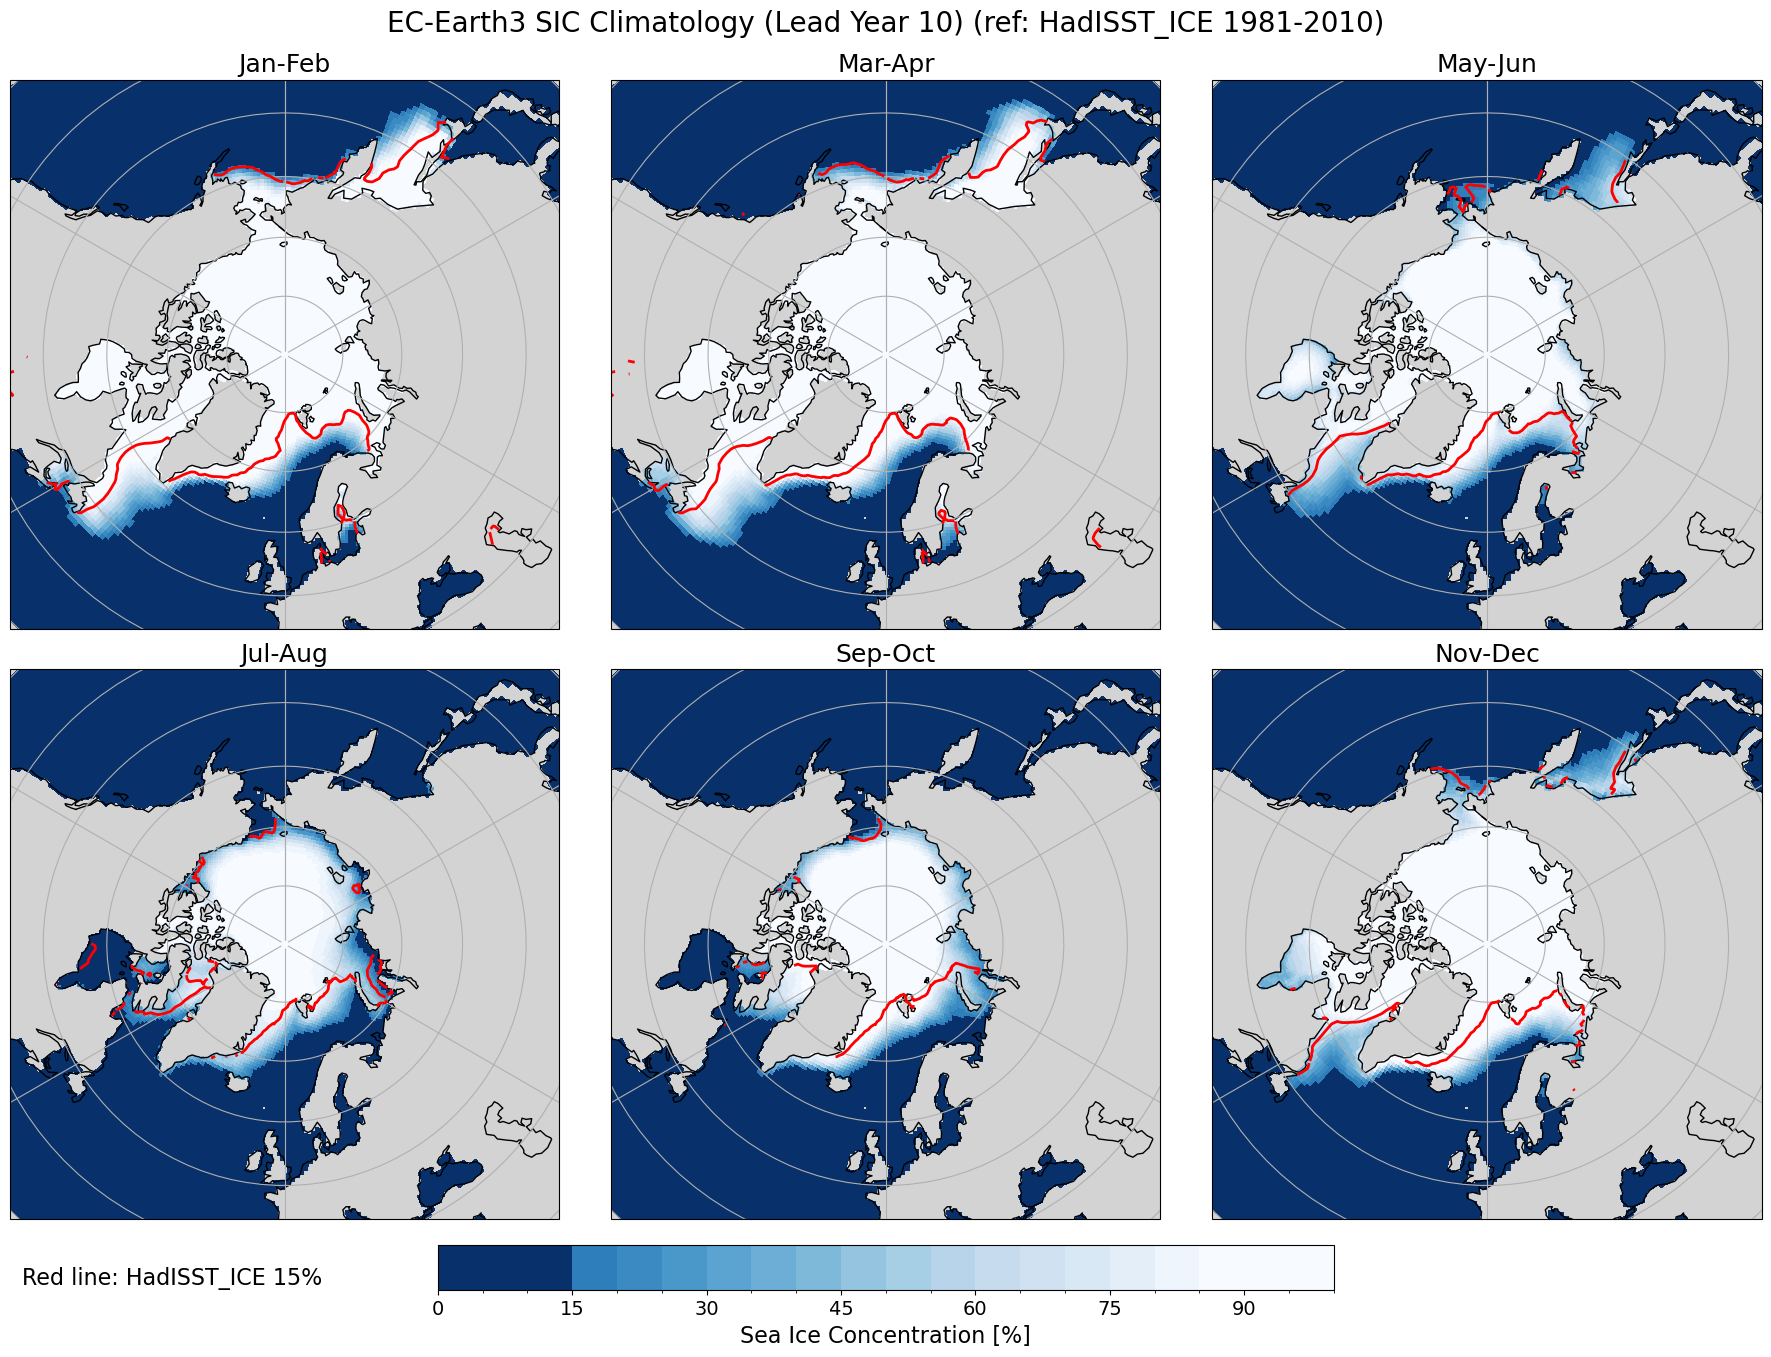

In [5]:
import matplotlib.colors as mcolors

ds_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
figout_dir = "/global/cfs/projectdirs/m4581/jungchoi/PMP/GMD2026/Fig2/_subplots"

var_name = "siconc"
case = "mon_clim1981-2010"

#model_list = ["CanESM5", "CMCC-CM2-SR5", "HadGEM3-GC31-MM", "CNRM-ESM2-1", "EC-Earth3", 
#              "MIROC6", "IPSL-CM6A-LR", "MRI-ESM2-0", "NorCPM1", "MPI-ESM1-2-HR" ]
model_list = ["EC-Earth3"]

region = "Arctic"
#region = "Antarctic"
exp = "DCPP"
#exp = "historical"

#Read observed climatology
obs_file = f"{ds_dir}/OBS/{var_name}.360x180.mon_clim1981-2010.nc"   
obs_ds = xr.open_dataset(obs_file)
obs_ds = obs_ds * 100.
print(obs_ds)
obs_ds.close()

for model in model_list:
    if exp == "historical":
        lead_end = 1
        lead_out = "historical"
        fn_out = "HIST"
    else:
        lead_end = 10
        if model in ["CNRM-ESM2-1", "MRI-ESM2-0"]:
            lead_end = 5
 
    for lead_yr in range(10, lead_end + 1):
        if exp == "DCPP":
            lead_out = f"YR{lead_yr}"
            fn_out = f"LY{lead_yr}"
                
        # Read model mean climatolovy
        mdl_file = f"{ds_dir}/{model}/{var_name}.{lead_out}.{case}.em.nc"    
        mdl_ds = xr.open_dataset(mdl_file)
        print(mdl_file, mdl_ds)

        if model == "CNRM-ESM2-1":
            mdl_ds = mdl_ds.rename({'lon': 'longitude', 'lat': 'latitude'})
        if model == "IPSL-CM6A-LR":
            mdl_ds = mdl_ds.rename({'nav_lon': 'longitude', 'nav_lat': 'latitude'})
        if model == "EC-Earth3":
            mdl_ds = ensure_latlon(mdl_ds)
            print('EC-Earth3 :', mdl_ds)
        if model == "MRI-ESM2-0":
            file_mri_lsm = "/pscratch/sd/j/jungchoi/DCPP/MRI/MRI-ESM2-0/sftof_Ofx_MRI-ESM2-0_historical_r1i1p1f1_gn.nc"
            mri_lsm = xr.open_dataset(file_mri_lsm)
            mri_mask = xr.where(mri_lsm['sftof'] == 100, 1, np.nan)
            mdl_ds['siconc'] = mdl_ds['siconc'] * mri_mask.values
            mri_lsm.close()   

        
        # Define bias and 2-month average
        obs_bimonthly_group = ((obs_ds['month'] - 1) // 2) + 1
        obs_bimonthly_means = obs_ds.groupby(obs_bimonthly_group).mean(dim='month')
        mdl_bimonthly_group = ((mdl_ds['month'] - 1) // 2) + 1
        mdl_bimonthly_means = mdl_ds.groupby(mdl_bimonthly_group).mean(dim='month')
        mdl_ds.close()
        ##print('mdl_+bimonthly_mean:', mdl_bimonthly_means)
        
        lons = obs_ds.longitude
        lats = obs_ds.latitude
        lon2d, lat2d = np.meshgrid(lons, lats)
        
        labels = ['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec']
        
        if region == "Arctic":
            fig, axs = plt.subplots(2, 3, figsize=(18, 13),
                                subplot_kw={'projection': ccrs.NorthPolarStereo()},
                                constrained_layout=True)
        if region == "Antarctic":
            fig, axs = plt.subplots(2, 3, figsize=(18, 13),
                                subplot_kw={'projection': ccrs.SouthPolarStereo()},
                                constrained_layout=True)
        
        # shading level
        levels = np.arange(0, 105, 5)  # 0,5,10,...,100
        #bone_cmap = plt.cm.bone(np.linspace(0.2, 0.5, 3))  # 어두운 톤 3개
        blues_r = plt.cm.Blues_r
        dark_color = blues_r(0.0)  # 가장 어두운 색
        dark_cmap = np.array([dark_color]*3)
        bright_cmap = blues_r(np.linspace(0.3, 1.1, 17))
        colors = np.vstack((dark_cmap, bright_cmap))
        custom_cmap = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(levels, ncolors=custom_cmap.N, clip=False)
        
        for i in range(6):
            row = i // 3
            col = i % 3
            ax = axs[row, col]
        
            mdl_i = mdl_bimonthly_means.sel(month=i+1)
            obs_i = obs_bimonthly_means.sel(month=i+1)
            ##print('mdl_i:', mdl_i)
            
            if region == "Arctic":
                mdl_polar = mdl_i.where(mdl_i['latitude'] >= 30)
                obs_polar = obs_i.where(obs_i['latitude'] >= 30)
                lat1 = 45
                lat2 = 90
        
            if region == "Antarctic":
                mdl_polar = mdl_i.where(mdl_i['latitude'] <= -30)
                obs_polar = obs_i.where(obs_i['latitude'] <= -30)
                lat1 = -90
                lat2 = -50
        
            #print('%%%%%%%%%% mdl==', mdl_polar)
            #print('%%%%%%%%%% obs==', obs_polar)
            mdl_data = mdl_polar['siconc']
            obs_data = obs_polar['siconc']
        
            #mdl_data = mdl_data.assign_coords(
            #    longitude=(((mdl_data.longitude + 180) % 360) - 180))
          
            ax.set_extent([-180, 180, lat1, lat2], crs=ccrs.PlateCarree())
            ax.coastlines()
            ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
            ax.gridlines(draw_labels=False)
        
           # mask = np.where(mdl_data >= 15, mdl_data, np.nan)
            im = ax.pcolormesh(
                mdl_i['longitude'], mdl_i['latitude'], mdl_data,
                transform=ccrs.PlateCarree(),
                cmap=custom_cmap, norm=norm,
                #shading='auto',
                #vmin=0, vmax=100
            )
        
            cs_obs = ax.contour(
                obs_i['longitude'], obs_i['latitude'], obs_data,
                levels=[15],               # 15 값 등고선만 그리기
                colors='red',              # 등고선 색깔
                linewidths=2,
                transform=ccrs.PlateCarree()
                )
        
            ax.set_facecolor('lightgray')
            ax.set_title(labels[i], fontsize=18)
        
        if exp == "DCPP":
            fig.suptitle(f"{model} SIC Climatology (Lead Year {lead_yr}) (ref: HadISST_ICE 1981-2010)", fontsize=20, y=1.03)
        if exp == "historical":
            fig.suptitle(f"{model} SIC Climatology (Historical) (ref: HadISST_ICE 1981-2010)", fontsize=20, y=1.03)
            
        cbar = fig.colorbar(im, ax=axs.ravel().tolist(), orientation='horizontal', pad=0.02, shrink=0.5)
        cbar.set_label('Sea Ice Concentration [%]', fontsize=16)
        cbar.ax.tick_params(labelsize=14) 
        
        fig.text(0.02, 0.045, 'Red line: HadISST_ICE 15%', fontsize=16, ha='left', va='bottom', color='black')

        #plt.savefig(f"{figout_dir}/Clim_SIC.{region}.{model}.{fn_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        #plt.savefig(f"_figs/_Fig4/Clim_SIC.{region}.{model}.{lead_out}.png", dpi=300, bbox_inches='tight', transparent=False)
        plt.savefig(f"_figs/Fig4.eps", dpi=300, bbox_inches='tight', transparent=False)
        plt.show()
